# Wind/price coupling calibration

This notebook calibrates the one-way coupling from the wind/weather CARMA
driver into the German electricity price CARMA driver.

The scope is intentionally narrow:

- keep the already calibrated marginal CARMA models fixed;
- estimate the coupling coefficient `lambda` using the state-residual covariance
  identity from the paper;
- remove the estimated wind component from the marginal price driver;
- fit the NIG distribution on the remaining idiosyncratic price driver.

No joint CARMA recalibration, pricing formula, or full simulation engine is added here.


## Mathematical model and estimator

Let \(S\) denote the wind/weather latent factor and \(P\) the deseasonalised
German log-price factor.

The calibrated marginal wind model is

$$
\begin{aligned}
dZ_t^S &= A_S Z_t^S\,dt + \sigma_S e_S\,dW_t^S, \\
Y_t^S &= b_S^\top Z_t^S .
\end{aligned}
$$

The coupled price model keeps the marginal price CARMA dynamics but adds the
wind/weather shock to the price driver:

$$
\begin{aligned}
dZ_t^P
&= A_P Z_t^P\,dt
   + \lambda \sigma_S e_P\,dW_t^S
   + e_P\,dL_t^{P,\mathrm{id}}, \\
Y_t^P &= b_P^\top Z_t^P .
\end{aligned}
$$

Here \(dL_t^{P,\mathrm{id}}\) is the price idiosyncratic driver and is assumed
independent of the wind Brownian shock \(dW_t^S\).

For a one-hour step \(\Delta\), the paper identifies \(\lambda\) from the state
residuals

$$
\begin{aligned}
R_t^S &= Z_{t+\Delta}^S - \exp(A_S\Delta) Z_t^S, \\
R_t^P &= Z_{t+\Delta}^P - \exp(A_P\Delta) Z_t^P .
\end{aligned}
$$

Using the integrated CARMA state equations and independence of
\(dW_t^S\) and \(dL_t^{P,\mathrm{id}}\),

$$
\operatorname{Cov}\!\left(R_t^S,R_t^P\right)
=
\lambda \sigma_S^2
\int_0^\Delta
\exp(A_S u)\,e_S e_P^\top\,\exp(A_P^\top u)\,du .
$$

Define the theoretical covariance response for \(\lambda=1\):

$$
K_{SP}
=
\sigma_S^2
\int_0^\Delta
\exp(A_S u)\,e_S e_P^\top\,\exp(A_P^\top u)\,du .
$$

The empirical covariance of filtered state residuals is

$$
\widehat D_{SP}
=
\frac{1}{n}
\sum_{i=1}^n
\left(\widehat R_i^S-\overline R^S\right)
\left(\widehat R_i^P-\overline R^P\right)^\top .
$$

Projecting the matrix identity through the CARMA output vectors gives the scalar
estimator used below:

$$
\widehat\lambda
=
\frac{
    b_S^\top \widehat D_{SP} b_P
}{
    b_S^\top K_{SP} b_P
}.
$$

The true states \(Z_t\) are latent, so the notebook uses plug-in residuals based on
marginal Kalman-filtered states \(\widehat Z_t\).


## 1. Setup and file locations

The notebook reads the current marginal calibration files:

- wind/weather CARMA(4,3): `wind_carma43_joint_qmle_result.json`;
- German price CARMA(5,4): `price_carma54_joint_qmle_result.json`;
- recovered marginal driver increments from the two marginal QMLE notebooks.

All coupling outputs are written to `wind/data/coupling`.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.stats import norm, norminvgauss, pearsonr

pd.set_option("display.precision", 12)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

HERE = Path.cwd().resolve()
if (HERE / "wind").exists() and (HERE / "germany").exists():
    PROJECT_ROOT = HERE
    HERE = PROJECT_ROOT / "wind" / "carma_coupling"
elif HERE.name.lower() == "carma_coupling" and HERE.parent.name.lower() == "wind":
    PROJECT_ROOT = HERE.parents[1]
else:
    raise FileNotFoundError("Run this notebook from the repo root or from wind/carma_coupling/.")

WIND_CARMA_DIR = HERE / "data" / "carma"
PRICE_KALMAN_DIR = PROJECT_ROOT / "germany" / "germany23+24+25" / "data" / "kalman"
PRICE_SEASONALITY_DIR = PROJECT_ROOT / "germany" / "germany23+24+25" / "data" / "seasonality"
COUPLING_DIR = HERE / "data" / "coupling"
COUPLING_DIR.mkdir(parents=True, exist_ok=True)

WIND_QMLE_PATH = WIND_CARMA_DIR / "wind_carma43_joint_qmle_result.json"
PRICE_QMLE_PATH = PRICE_KALMAN_DIR / "price_carma54_joint_qmle_result.json"
WIND_PANEL_PATH = WIND_CARMA_DIR / "wind_latent_panel.csv"
PRICE_PANEL_PATH = PRICE_SEASONALITY_DIR / "german_panel.csv"
WIND_INCREMENTS_PATH = WIND_CARMA_DIR / "wind_carma43_levy_increments_recovered.npz"
PRICE_INCREMENTS_PATH = PRICE_KALMAN_DIR / "price_carma54_levy_increments_recovered.npz"


## 2. Helper functions

The CARMA companion matrix follows the same convention as notebooks 03 and 05.
For each marginal model, the one-step transition matrix is

$$
F_\Delta = \exp(A\Delta).
$$

Van Loan's block exponential is used to compute the exact Gaussian transition
covariance

$$
Q_\Delta
=
\int_0^\Delta
\exp(Au)\,G G^\top\,\exp(A^\top u)\,du .
$$

The same construction is used for the cross-covariance kernel \(K_{SP}\).


In [2]:
def companion_from_ar(ar_coefficients):
    # Companion matrix convention used by notebooks 03/05.
    a = np.asarray(ar_coefficients, dtype=float)
    p = len(a)
    A = np.zeros((p, p), dtype=float)
    if p > 1:
        A[:-1, 1:] = np.eye(p - 1)
    A[-1, :] = -a[::-1]
    return A


def build_carma_from_qmle(path):
    with open(path, "r", encoding="utf-8") as f:
        obj = json.load(f)
    A = companion_from_ar(obj["ar_coefficients"])
    b = np.asarray(obj["b_coefficients"], dtype=float)
    e = np.zeros(A.shape[0], dtype=float)
    e[-1] = 1.0
    sigma = float(np.sqrt(obj["nu2_qmle"]))
    order = tuple(int(x) for x in obj["carma_order"])
    return {
        "path": str(path),
        "json": obj,
        "order": order,
        "A": A,
        "b": b,
        "e": e,
        "sigma": sigma,
        "nu2": float(obj["nu2_qmle"]),
        "m": float(obj["m_qmle"]),
        "stationary_mean": float(obj.get("stationary_mean", np.nan)),
    }


def van_loan(A, G, dt):
    # Discrete transition F and covariance Q for dZ = A Z dt + G dW.
    n = A.shape[0]
    M = np.block([[A, G @ G.T], [np.zeros((n, n)), -A.T]]) * float(dt)
    E = expm(M)
    F = E[:n, :n]
    Q = E[:n, n:] @ F.T
    return F, 0.5 * (Q + Q.T)


def stationary_covariance(A, G):
    P = solve_continuous_lyapunov(A, -(G @ G.T))
    return 0.5 * (P + P.T)


def kf_scalar(y, A, G, H, dt=1.0, obs_noise=1e-8):
    # Scalar-output Kalman filter used only to recover marginal CARMA states.
    y = np.asarray(y, dtype=float)
    H = np.asarray(H, dtype=float).reshape(-1)
    p = A.shape[0]
    F, Q = van_loan(A, G, dt)
    x = np.zeros(p, dtype=float)
    P = stationary_covariance(A, G) + np.eye(p) * 1e-8

    xs = np.zeros((len(y), p), dtype=float)
    innov = np.zeros(len(y), dtype=float)
    S_arr = np.zeros(len(y), dtype=float)
    loglik = 0.0
    I = np.eye(p)

    for k, obs in enumerate(y):
        if k > 0:
            x = F @ x
            P = F @ P @ F.T + Q

        mu = float(H @ x)
        S = max(float(H @ P @ H) + obs_noise, 1e-14)
        v = float(obs - mu)
        K = (P @ H) / S
        x = x + K * v
        P = (I - np.outer(K, H)) @ P
        P = 0.5 * (P + P.T)

        xs[k] = x
        innov[k] = v
        S_arr[k] = S
        loglik += -0.5 * (np.log(2 * np.pi * S) + v * v / S)

    return {"F": F, "Q": Q, "x": xs, "innov": innov, "S": S_arr, "loglik": float(loglik)}


def cross_covariance_kernel(A_s, A_p, e_s, e_p, sigma_s, dt=1.0):
    # K_SP = sigma_s^2 int exp(A_s u)e_s e_p' exp(A_p' u) du.
    p_s, p_p = len(e_s), len(e_p)
    A = np.zeros((p_s + p_p, p_s + p_p), dtype=float)
    A[:p_s, :p_s] = A_s
    A[p_s:, p_s:] = A_p
    G = np.zeros((p_s + p_p, 1), dtype=float)
    G[:p_s, 0] = sigma_s * e_s
    G[p_s:, 0] = sigma_s * e_p
    _, Q = van_loan(A, G, dt)
    return Q[:p_s, p_s:]


def centered_cross_moment_matrix(X, Y):
    Xc = X - X.mean(axis=0, keepdims=True)
    Yc = Y - Y.mean(axis=0, keepdims=True)
    return (Xc.T @ Yc) / len(Xc)


def fit_nig(x):
    x = np.asarray(x, dtype=float)
    try:
        a, b, loc, scale = norminvgauss.fit(x, method="MLE")
    except TypeError:
        a, b, loc, scale = norminvgauss.fit(x)

    ll = float(norminvgauss.logpdf(x, a, b, loc=loc, scale=scale).sum())
    alpha = float(a / scale)
    beta = float(b / scale)
    delta = float(scale)
    mu = float(loc)
    gamma = float(np.sqrt(max(alpha * alpha - beta * beta, 0.0)))
    mean = float(mu + delta * beta / gamma) if gamma > 0 else np.nan
    var = float(delta * alpha * alpha / (gamma ** 3)) if gamma > 0 else np.nan

    return {
        "scipy_a": float(a),
        "scipy_b": float(b),
        "loc": float(loc),
        "scale": float(scale),
        "alpha": alpha,
        "beta": beta,
        "delta": delta,
        "mu": mu,
        "gamma": gamma,
        "mean": mean,
        "variance": var,
        "std": float(np.sqrt(var)) if var >= 0 else np.nan,
        "loglik": ll,
        "AIC": float(-2 * ll + 2 * 4),
        "BIC": float(-2 * ll + 4 * np.log(len(x))),
    }


def moments(x):
    s = pd.Series(np.asarray(x, dtype=float))
    return {
        "n": int(s.size),
        "mean": float(s.mean()),
        "std": float(s.std(ddof=1)),
        "skew": float(s.skew()),
        "excess_kurtosis": float(s.kurtosis()),
        "q01": float(s.quantile(0.01)),
        "q05": float(s.quantile(0.05)),
        "median": float(s.quantile(0.50)),
        "q95": float(s.quantile(0.95)),
        "q99": float(s.quantile(0.99)),
    }


## 3. Load the marginal CARMA models

Only the already calibrated marginal parameters are loaded here. The matrices
for wind and price are not re-estimated in this notebook.


In [3]:
wind_model = build_carma_from_qmle(WIND_QMLE_PATH)
price_model = build_carma_from_qmle(PRICE_QMLE_PATH)

model_table = pd.DataFrame(
    {
        "CARMA_order": [wind_model["order"], price_model["order"]],
        "state_dim_p": [wind_model["A"].shape[0], price_model["A"].shape[0]],
        "sigma_sqrt_nu2": [wind_model["sigma"], price_model["sigma"]],
        "nu2": [wind_model["nu2"], price_model["nu2"]],
        "driver_drift_m": [wind_model["m"], price_model["m"]],
    },
    index=["wind_weather", "price_germany"],
)
display(model_table)


,CARMA_order,state_dim_p,sigma_sqrt_nu2,nu2,driver_drift_m
wind_weather,"(4, 3)",4,0.315190203229,0.099344864212,0.000015728344
price_germany,"(5, 4)",5,0.013242411630,0.000175361466,0.000008473621


## 4. Load and align residual panels

Both the wind panel and price panel are timestamped in UTC. The observed
residual levels are centred before marginal filtering:

$$
\widetilde Y_t^T = Y_t^T - \overline Y^T,
\qquad
\widetilde Y_t^P = Y_t^P - \overline Y^P .
$$

This removes deterministic level offsets and lets the Kalman filters focus on
the stochastic CARMA state around zero.


In [4]:
wind_panel = pd.read_csv(WIND_PANEL_PATH, index_col=0, parse_dates=True)
wind_utc_time = pd.DatetimeIndex(pd.to_datetime(wind_panel.index, utc=True))
wind_y_raw = wind_panel["wind_XtQ"].to_numpy(float)

price_panel = pd.read_csv(PRICE_PANEL_PATH, parse_dates=["datetime"])
price_utc_time = pd.DatetimeIndex(pd.to_datetime(price_panel["datetime"], utc=True))
price_y_raw = price_panel["log_price_resid"].to_numpy(float)

if not np.isfinite(wind_y_raw).all():
    raise ValueError("wind_XtQ contains non-finite values; this notebook expects the calibrated panel.")
if not np.isfinite(price_y_raw).all():
    raise ValueError("log_price_resid contains non-finite values; this notebook expects the calibrated panel.")

wind_y = wind_y_raw - float(np.mean(wind_y_raw))
price_y = price_y_raw - float(np.mean(price_y_raw))

panel_table = pd.DataFrame(
    {
        "n_obs": [len(wind_y), len(price_y)],
        "start_utc": [wind_utc_time.min(), price_utc_time.min()],
        "end_utc": [wind_utc_time.max(), price_utc_time.max()],
        "centered_std": [float(np.std(wind_y, ddof=1)), float(np.std(price_y, ddof=1))],
    },
    index=["wind_XtQ", "price_log_resid"],
)
display(panel_table)


,n_obs,start_utc,end_utc,centered_std
wind_XtQ,26305,2023-01-01 00:00:00+00:00,2026-01-01 00:00:00+00:00,1.299102870961
price_log_resid,26305,2023-01-01 00:00:00+00:00,2026-01-01 00:00:00+00:00,0.035452594414


## 5. Recover state residuals

For each marginal CARMA model, a scalar-output Kalman filter gives estimated
states \(\widehat Z_t\). The empirical one-step residuals are then

$$
\begin{aligned}
\widehat R_i^S
&=
\widehat Z_{t_i+\Delta}^S
-
\exp(A_S\Delta)\widehat Z_{t_i}^S, \\
\widehat R_i^P
&=
\widehat Z_{t_i+\Delta}^P
-
\exp(A_P\Delta)\widehat Z_{t_i}^P .
\end{aligned}
$$

Only common UTC intervals with

$$
\Delta = 1 \text{ hour}
$$

are kept. Non-one-hour intervals caused by timezone transitions are excluded
before estimating the covariance.


In [5]:
from scipy.linalg import expm, solve_continuous_lyapunov

In [6]:
h = 1.0

A_s, b_s, e_s, sigma_s = wind_model["A"], wind_model["b"], wind_model["e"], wind_model["sigma"]
A_p, b_p, e_p, sigma_p = price_model["A"], price_model["b"], price_model["e"], price_model["sigma"]

kf_s = kf_scalar(wind_y, A_s, sigma_s * e_s[:, None], b_s, dt=h)
kf_p = kf_scalar(price_y, A_p, sigma_p * e_p[:, None], b_p, dt=h)

R_s = kf_s["x"][1:] - (kf_s["F"] @ kf_s["x"][:-1].T).T
R_p = kf_p["x"][1:] - (kf_p["F"] @ kf_p["x"][:-1].T).T

wind_start_utc = wind_utc_time[:-1]
wind_end_utc = wind_utc_time[1:]
price_start_utc = price_utc_time[:-1]
price_end_utc = price_utc_time[1:]

wind_dt_h = (wind_end_utc - wind_start_utc) / pd.Timedelta(hours=1)
price_dt_h = (price_end_utc - price_start_utc) / pd.Timedelta(hours=1)

wind_intervals = pd.DataFrame(
    {"datetime": wind_end_utc, "i_s": np.arange(len(R_s), dtype=int), "dt_s_h": np.asarray(wind_dt_h, dtype=float)}
)
price_intervals = pd.DataFrame(
    {"datetime": price_end_utc, "i_p": np.arange(len(R_p), dtype=int), "dt_p_h": np.asarray(price_dt_h, dtype=float)}
)

wind_intervals = wind_intervals.dropna(subset=["datetime"])
price_intervals = price_intervals.dropna(subset=["datetime"])
wind_intervals = wind_intervals[np.isclose(wind_intervals["dt_s_h"], 1.0)]
price_intervals = price_intervals[np.isclose(price_intervals["dt_p_h"], 1.0)]
wind_intervals = wind_intervals.drop_duplicates("datetime", keep="first")
price_intervals = price_intervals.drop_duplicates("datetime", keep="first")

common = wind_intervals.merge(price_intervals, on="datetime", how="inner").sort_values("datetime")
idx_s = common["i_s"].to_numpy(int)
idx_p = common["i_p"].to_numpy(int)

R_s_c = R_s[idx_s]
R_p_c = R_p[idx_p]
n_common = len(common)

if n_common < 100:
    raise RuntimeError(f"Too few common hourly residual intervals: {n_common}")

alignment_summary = pd.DataFrame(
    {
        "common_hourly_intervals": [n_common],
        "start_utc": [common["datetime"].min()],
        "end_utc": [common["datetime"].max()],
    }
)
display(alignment_summary)


,common_hourly_intervals,start_utc,end_utc
0,26304,2023-01-01 01:00:00+00:00,2026-01-01 00:00:00+00:00


## 6. Estimate the coupling coefficient

The covariance estimator is centred:

$$
\widehat D_{SP}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left(\widehat R_i^S-\overline R^S\right)
\left(\widehat R_i^P-\overline R^P\right)^\top .
$$

The theoretical response to a unit coupling is

$$
K_{SP}
=
\sigma_S^2
\int_0^\Delta
\exp(A_Su)\,e_S e_P^\top\,\exp(A_P^\top u)\,du .
$$

The coupling estimate is

$$
\widehat\lambda
=
\frac{
    b_S^\top \widehat D_{SP} b_P
}{
    b_S^\top K_{SP} b_P
}.
$$

Interpretation of the sign: `wind_XtQ` is a deseasonalised wind residual. Thus `lambda_hat > 0` means that a positive wind shock raises the price factor in the coupled driver.


In [7]:
D_sp_hat = centered_cross_moment_matrix(R_s_c, R_p_c)
K_sp = cross_covariance_kernel(A_s, A_p, e_s, e_p, sigma_s, dt=h)

num = float(b_s @ D_sp_hat @ b_p)
den = float(b_s @ K_sp @ b_p)
lambda_hat = float(num / den)

r_s_out = R_s_c @ b_s
r_p_out = R_p_c @ b_p
emp_output_cov = float(np.mean((r_s_out - r_s_out.mean()) * (r_p_out - r_p_out.mean())))
model_output_cov = float(lambda_hat * den)

var_r_s = float(np.mean((r_s_out - r_s_out.mean()) ** 2))
var_r_p = float(np.mean((r_p_out - r_p_out.mean()) ** 2))
state_resid_corr = float(emp_output_cov / np.sqrt(var_r_s * var_r_p))

lambda_table = pd.DataFrame(
    {
        "lambda_hat": [lambda_hat],
        "n_common": [n_common],
        "numerator_bDb": [num],
        "denominator_bKb": [den],
        "empirical_output_cov": [emp_output_cov],
        "model_output_cov": [model_output_cov],
        "state_residual_output_corr": [state_resid_corr],
    }
)

display(lambda_table[["lambda_hat", "n_common", "state_residual_output_corr"]])


,lambda_hat,n_common,state_residual_output_corr
0,-0.001691295958,26304,-0.040240976391


## 7. Build the idiosyncratic price driver

The recovered marginal price driver already contains any wind component present
in historical prices. After estimating \(\lambda\), the idiosyncratic price driver is
defined by

$$
dL_{t_i}^{P,\mathrm{id}}
=
dL_{t_i}^{P,\mathrm{marg}}
-
\widehat\lambda\,dL_{t_i}^{S}.
$$

The subtraction uses raw aligned increments. Demeaning is used only for covariance
and correlation diagnostics, not for constructing \(dL^{P,\mathrm{id}}\).

The simple OLS slope on recovered increments,

$$
\widehat\lambda_{\mathrm{OLS}}
=
\frac{
    \sum_i
    \left(dL_i^{P,\mathrm{marg}}-\overline{dL}^{P,\mathrm{marg}}\right)
    \left(dL_i^{S}-\overline{dL}^{S}\right)
}{
    \sum_i
    \left(dL_i^{S}-\overline{dL}^{S}\right)^2
},
$$

is reported only as a sanity check. It is not the estimator used for the model.


In [8]:
wind_npz = np.load(WIND_INCREMENTS_PATH)
price_npz = np.load(PRICE_INCREMENTS_PATH)
dL_wind_all = wind_npz["increments"].astype(float)
dL_price_all = price_npz["increments"].astype(float)

if len(dL_wind_all) != len(R_s):
    raise ValueError(f"wind increment length {len(dL_wind_all)} != state residual length {len(R_s)}")
if len(dL_price_all) != len(R_p):
    raise ValueError(f"price increment length {len(dL_price_all)} != state residual length {len(R_p)}")

dW_wind = dL_wind_all[idx_s]
dW_price_marginal = dL_price_all[idx_p]
dL_price_idio = dW_price_marginal - lambda_hat * dW_wind

dWs_c = dW_wind - dW_wind.mean()
dWp_c = dW_price_marginal - dW_price_marginal.mean()
lambda_ols_increments = float(np.dot(dWp_c, dWs_c) / np.dot(dWs_c, dWs_c))

driver_moments = pd.DataFrame(
    {
        "wind_driver": moments(dW_wind),
        "price_marginal_driver": moments(dW_price_marginal),
        "price_idiosyncratic_driver": moments(dL_price_idio),
    }
).T

driver_corr = pd.DataFrame(
    {
        "corr_price_marginal_wind": [float(pearsonr(dW_price_marginal, dW_wind).statistic)],
        "corr_price_idio_wind": [float(pearsonr(dL_price_idio, dW_wind).statistic)],
        "lambda_ols_on_increments_diagnostic": [lambda_ols_increments],
        "lambda_state_residual_method": [lambda_hat],
    }
)

essential_driver_diagnostics = pd.DataFrame(
    {
        "value": {
            "lambda_state_residual_method": lambda_hat,
            "lambda_ols_on_increments_diagnostic": lambda_ols_increments,
            "corr_price_marginal_wind": driver_corr["corr_price_marginal_wind"].iloc[0],
            "corr_price_idio_wind": driver_corr["corr_price_idio_wind"].iloc[0],
            "mean_price_marginal": float(np.mean(dW_price_marginal)),
            "std_price_marginal": float(np.std(dW_price_marginal, ddof=1)),
            "mean_price_idio": float(np.mean(dL_price_idio)),
            "std_price_idio": float(np.std(dL_price_idio, ddof=1)),
        }
    }
)
display(essential_driver_diagnostics)


,value
lambda_state_residual_method,-0.001691295958
lambda_ols_on_increments_diagnostic,-0.001689749368
corr_price_marginal_wind,-0.040236636950
corr_price_idio_wind,0.000036857555
mean_price_marginal,0.000001890646
std_price_marginal,0.013235884839
mean_price_idio,0.000001419795
std_price_idio,0.013225166146


## 8. Fit the NIG law on the idiosyncratic driver

The NIG distribution is fitted to \(dL^{P,\mathrm{id}}\), not to the marginal price
driver.

SciPy's `norminvgauss` uses parameters \((a,b,\mathrm{loc},\mathrm{scale})\). The
usual NIG notation is recovered by

$$
\begin{aligned}
\delta &= \mathrm{scale}, \\
\mu &= \mathrm{loc}, \\
\alpha &= \frac{a}{\delta}, \\
\beta &= \frac{b}{\delta}, \\
\gamma &= \sqrt{\alpha^2-\beta^2}.
\end{aligned}
$$

The fitted NIG mean and variance are

$$
\mathbb E[X]
=
\mu + \delta\frac{\beta}{\gamma},
\qquad
\operatorname{Var}(X)
=
\delta\frac{\alpha^2}{\gamma^3}.
$$

These fitted parameters are the ones to use later for simulating the
idiosyncratic price shock.


In [9]:
nig_idio = fit_nig(dL_price_idio)
gauss_idio_mu, gauss_idio_sig = norm.fit(dL_price_idio)
ll_gauss_idio = float(norm.logpdf(dL_price_idio, gauss_idio_mu, gauss_idio_sig).sum())

fit_table = pd.DataFrame(
    [
        {
            "series": "price_idiosyncratic_driver",
            "model": "Gaussian",
            "mean": float(gauss_idio_mu),
            "std": float(gauss_idio_sig),
            "loglik": ll_gauss_idio,
            "AIC": float(-2 * ll_gauss_idio + 2 * 2),
            "BIC": float(-2 * ll_gauss_idio + 2 * np.log(len(dL_price_idio))),
        },
        {
            "series": "price_idiosyncratic_driver",
            "model": "NIG",
            "mean": nig_idio["mean"],
            "std": nig_idio["std"],
            "loglik": nig_idio["loglik"],
            "AIC": nig_idio["AIC"],
            "BIC": nig_idio["BIC"],
            "alpha": nig_idio["alpha"],
            "beta": nig_idio["beta"],
            "delta": nig_idio["delta"],
            "mu": nig_idio["mu"],
        },
    ]
)

nig_param_table = pd.DataFrame([nig_idio], index=["price_idiosyncratic_driver_NIG"]).T
nig_display = pd.DataFrame(
    {
        "value": {
            "alpha": nig_idio["alpha"],
            "beta": nig_idio["beta"],
            "delta": nig_idio["delta"],
            "mu": nig_idio["mu"],
            "mean": nig_idio["mean"],
            "std": nig_idio["std"],
            "loglik": nig_idio["loglik"],
        }
    }
)
display(nig_display)


,value
alpha,47.346305149773
beta,-4.879734440543
delta,0.006839152013
mu,0.000709386259
mean,0.000000737058
std,0.012115365122
loglik,83508.057174957794


## 9. Distribution check: marginal driver, idiosyncratic NIG, and wind Gaussian component

The coupled model decomposes the marginal price driver as

$$
dL_t^{P,\mathrm{marg}}
\approx
dL_t^{P,\mathrm{id}}
+
\widehat\lambda\,dL_t^S .
$$

The two stochastic components used for simulation are therefore:

$$
dL_t^{P,\mathrm{id}} \sim \mathrm{NIG},
\qquad
\widehat\lambda\,dL_t^S \sim \mathcal N
\left(
    \widehat\lambda\,\mu_S,\,
    \widehat\lambda^2\sigma_S^2
\right).
$$

The figure below shows:

- the empirical marginal price driver \(dL^{P,\mathrm{marg}}\), as a reference;
- the NIG fit of the idiosyncratic price driver \(dL^{P,\mathrm{id}}\);
- the Gaussian fit of the transmitted wind/weather component
  \(\widehat\lambda dL^S\).

The transmitted Gaussian component is much narrower than the price driver. It is
therefore plotted with a secondary density axis and with a zoomed panel.


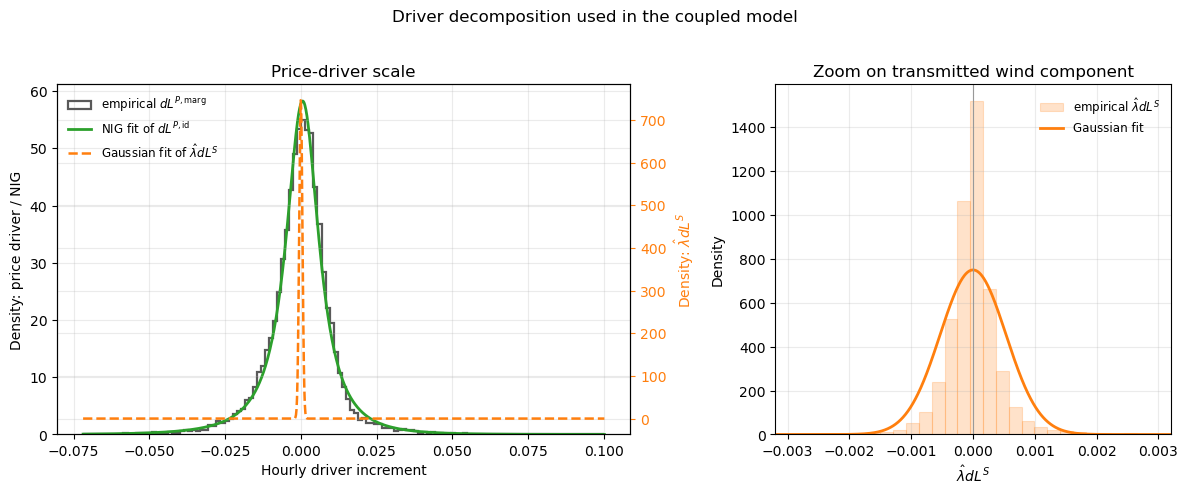

,mean,std
price_marginal_driver,0.000001890646,0.013235884839
price_idiosyncratic_driver,0.000001419795,0.013225166146
lambda_times_wind_driver,0.000000470851,0.000533044808


In [10]:
lambda_wind_component = lambda_hat * dW_wind
mu_lambda_wind, sig_lambda_wind = norm.fit(lambda_wind_component)

x_lo = float(np.quantile(np.r_[dW_price_marginal, dL_price_idio], 0.001))
x_hi = float(np.quantile(np.r_[dW_price_marginal, dL_price_idio], 0.999))
x_grid = np.linspace(x_lo, x_hi, 1000)

wind_width = max(6.0 * sig_lambda_wind, 1e-8)
x_zoom = np.linspace(mu_lambda_wind - wind_width, mu_lambda_wind + wind_width, 800)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), gridspec_kw={"width_ratios": [1.45, 1.0]})

# Left panel: price-driver scale, with a secondary y-axis for the very narrow Gaussian component.
ax = axes[0]
bins = np.linspace(x_lo, x_hi, 130)
ax.hist(
    dW_price_marginal,
    bins=bins,
    density=True,
    histtype="step",
    lw=1.6,
    color="0.35",
    label=r"empirical $dL^{P,\mathrm{marg}}$",
)
ax.plot(
    x_grid,
    norminvgauss.pdf(
        x_grid,
        nig_idio["scipy_a"],
        nig_idio["scipy_b"],
        loc=nig_idio["loc"],
        scale=nig_idio["scale"],
    ),
    lw=2.0,
    color="tab:green",
    label=r"NIG fit of $dL^{P,\mathrm{id}}$",
)
ax.set_title("Price-driver scale")
ax.set_xlabel("Hourly driver increment")
ax.set_ylabel("Density: price driver / NIG")

ax2 = ax.twinx()
ax2.plot(
    x_grid,
    norm.pdf(x_grid, mu_lambda_wind, sig_lambda_wind),
    ls="--",
    lw=1.8,
    color="tab:orange",
    label=r"Gaussian fit of $\hat\lambda dL^S$",
)
ax2.set_ylabel(r"Density: $\hat\lambda dL^S$", color="tab:orange")
ax2.tick_params(axis="y", colors="tab:orange")

lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2, frameon=False, fontsize=8.5, loc="upper left")

# Right panel: zoomed wind component.
ax = axes[1]
ax.hist(
    lambda_wind_component,
    bins=80,
    density=True,
    alpha=0.22,
    color="tab:orange",
    edgecolor="tab:orange",
    lw=0.8,
    label=r"empirical $\hat\lambda dL^S$",
)
ax.plot(
    x_zoom,
    norm.pdf(x_zoom, mu_lambda_wind, sig_lambda_wind),
    color="tab:orange",
    lw=2.0,
    label="Gaussian fit",
)
ax.axvline(0.0, color="0.6", lw=0.8)
ax.set_xlim(x_zoom[0], x_zoom[-1])
ax.set_title("Zoom on transmitted wind component")
ax.set_xlabel(r"$\hat\lambda dL^S$")
ax.set_ylabel("Density")
ax.legend(frameon=False, fontsize=8.5)

fig.suptitle("Driver decomposition used in the coupled model", y=1.02)
fig.tight_layout()
fig.savefig(COUPLING_DIR / "price_driver_marginal_nig_and_lambda_wind_gaussian.png", dpi=160, bbox_inches="tight")
plt.show()

component_distribution_summary = pd.DataFrame(
    {
        "mean": [
            float(np.mean(dW_price_marginal)),
            float(np.mean(dL_price_idio)),
            float(mu_lambda_wind),
        ],
        "std": [
            float(np.std(dW_price_marginal, ddof=1)),
            float(np.std(dL_price_idio, ddof=1)),
            float(sig_lambda_wind),
        ],
    },
    index=[
        "price_marginal_driver",
        "price_idiosyncratic_driver",
        "lambda_times_wind_driver",
    ],
)
display(component_distribution_summary)


## 10. Save artefacts for downstream simulation

For simulation, first generate the wind/weather driver and the idiosyncratic price
driver independently:

$$
dL_t^{S,\mathrm{sim}}
\quad\text{and}\quad
dL_t^{P,\mathrm{id,sim}}.
$$

Then build the total price driver as

$$
dL_t^{P,\mathrm{total,sim}}
=
dL_t^{P,\mathrm{id,sim}}
+
\widehat\lambda\,dL_t^{S,\mathrm{sim}}.
$$

Do not simulate

$$
dL_t^{P,\mathrm{marginal,NIG,sim}}
+
\widehat\lambda\,dL_t^{S,\mathrm{sim}},
$$

because the marginal price driver already contains the historical wind component.
Adding the wind shock again would double-count that effect.


In [11]:
timestamps = common["datetime"].dt.strftime("%Y-%m-%dT%H:%M:%SZ").to_numpy()

diagnostics = {
    "method": "state_residual_covariance_matching",
    "paper_reference": "Gachon-Karbach Proposition 2.10 covariance of residuals",
    "wind_factor": "wind_XtQ: deseasonalised wind residual",
    "timezone_policy": "wind and price timestamps interpreted as UTC; non-1h intervals dropped",
    "lambda_hat": lambda_hat,
    "n_common_hourly_intervals": int(n_common),
    "corr_price_marginal_wind": float(driver_corr["corr_price_marginal_wind"].iloc[0]),
    "corr_price_idio_wind": float(driver_corr["corr_price_idio_wind"].iloc[0]),
    "lambda_ols_on_increments_diagnostic": lambda_ols_increments,
    "carma": {
        "wind": {"order": wind_model["order"], "path": str(WIND_QMLE_PATH), "nu2": wind_model["nu2"]},
        "price": {"order": price_model["order"], "path": str(PRICE_QMLE_PATH), "nu2": price_model["nu2"]},
    },
    "nig_price_idiosyncratic_driver": nig_idio,
    "simulation_identity": "dW_price_total_sim = dL_price_idio_sim + lambda_hat * dW_wind_sim",
    "warning": "Do not simulate marginal_NIG_price + lambda_hat*dW_wind_sim; that double-counts wind.",
}

with open(COUPLING_DIR / "wind_price_coupling_result.json", "w", encoding="utf-8") as f:
    json.dump(diagnostics, f, indent=2, default=lambda o: list(o) if isinstance(o, tuple) else o)

lambda_table.to_csv(COUPLING_DIR / "wind_price_lambda_diagnostics.csv", index=False)
driver_moments.to_csv(COUPLING_DIR / "wind_price_driver_moments.csv", index_label="series")
driver_corr.to_csv(COUPLING_DIR / "wind_price_driver_correlations.csv", index=False)
fit_table.to_csv(COUPLING_DIR / "price_idiosyncratic_driver_fit_comparison.csv", index=False)
pd.DataFrame([nig_idio]).to_json(
    COUPLING_DIR / "price_idiosyncratic_driver_nig.json",
    orient="records",
    indent=2,
)

np.savez_compressed(
    COUPLING_DIR / "wind_price_aligned_drivers.npz",
    timestamps=timestamps,
    dW_wind=dW_wind,
    dW_price_marginal=dW_price_marginal,
    dL_price_idio=dL_price_idio,
    lambda_wind_component=lambda_wind_component,
    lambda_hat=np.array([lambda_hat]),
)

print(f"Saved compact coupling artefacts to: {COUPLING_DIR}")


Saved compact coupling artefacts to: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\wind\carma_coupling\data\coupling


## 11. Scatter diagnostics: raw residuals and state residuals

The raw residual scatter uses the residual levels read directly from the CSV
panels:

$$
\left(Y_t^S,\,Y_t^P\right).
$$

The state-residual scatter uses the paper residuals computed from filtered states:

$$
\begin{aligned}
\widehat R_t^S
&=
\widehat Z_{t+\Delta}^S
-
\exp(A_S\Delta)\widehat Z_t^S, \\
\widehat R_t^P
&=
\widehat Z_{t+\Delta}^P
-
\exp(A_P\Delta)\widehat Z_t^P .
\end{aligned}
$$

Since \(\widehat R_t^S\) and \(\widehat R_t^P\) are vectors, the plot uses their
observable CARMA projections:

$$
\left(
b_S^\top \widehat R_t^S,\,
b_P^\top \widehat R_t^P
\right).
$$

The second scatter is therefore the one directly related to the scalar covariance
used in the estimator of \(\lambda\).


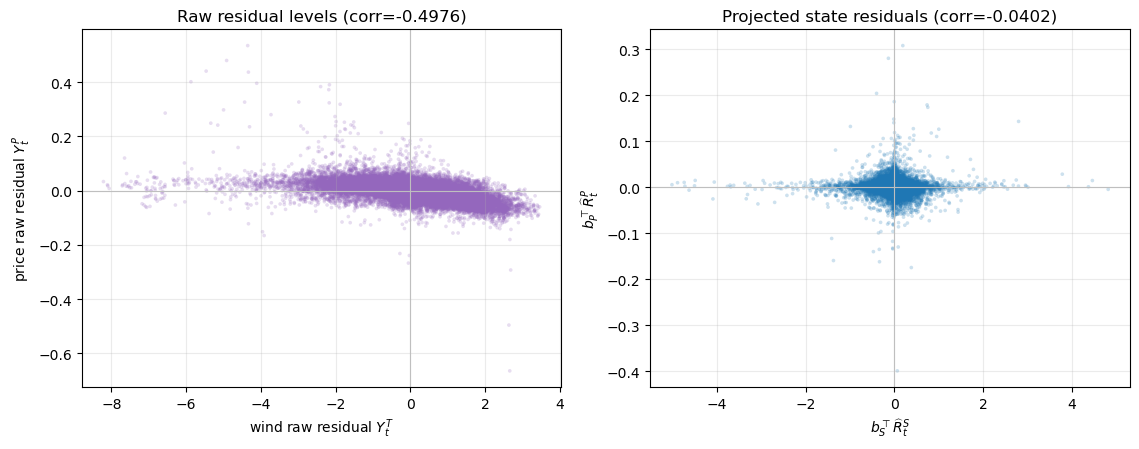

In [12]:
raw_wind_df = pd.DataFrame(
    {
        "datetime": wind_utc_time,
        "wind_raw_residual": wind_y_raw,
    }
).dropna(subset=["datetime"])
raw_price_df = pd.DataFrame(
    {
        "datetime": price_utc_time,
        "price_raw_residual": price_y_raw,
    }
).dropna(subset=["datetime"])

raw_wind_df = raw_wind_df.drop_duplicates("datetime", keep="first")
raw_price_df = raw_price_df.drop_duplicates("datetime", keep="first")
raw_common = raw_wind_df.merge(raw_price_df, on="datetime", how="inner").sort_values("datetime")

raw_corr = float(pearsonr(raw_common["wind_raw_residual"], raw_common["price_raw_residual"]).statistic)
state_corr = float(pearsonr(r_s_out, r_p_out).statistic)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

axes[0].scatter(
    raw_common["wind_raw_residual"],
    raw_common["price_raw_residual"],
    s=7,
    alpha=0.22,
    color="tab:purple",
    edgecolors="none",
    rasterized=True,
)
axes[0].axhline(0.0, color="0.75", lw=0.8)
axes[0].axvline(0.0, color="0.75", lw=0.8)
axes[0].set_title(f"Raw residual levels (corr={raw_corr:.4f})")
axes[0].set_xlabel(r"wind raw residual $Y^T_t$")
axes[0].set_ylabel(r"price raw residual $Y^P_t$")

axes[1].scatter(
    r_s_out,
    r_p_out,
    s=7,
    alpha=0.22,
    color="tab:blue",
    edgecolors="none",
    rasterized=True,
)
axes[1].axhline(0.0, color="0.75", lw=0.8)
axes[1].axvline(0.0, color="0.75", lw=0.8)
axes[1].set_title(f"Projected state residuals (corr={state_corr:.4f})")
axes[1].set_xlabel(r"$b_S^\top \widehat R^S_t$")
axes[1].set_ylabel(r"$b_P^\top \widehat R^P_t$")

fig.tight_layout()
fig.savefig(COUPLING_DIR / "wind_price_raw_and_state_residual_scatter.png", dpi=160)
plt.show()
